## Olof Sporn - Network Science Exploration

In [10]:
import os
import importlib
import numpy as np, pandas as pd, networkx as nx
import Project1.A3.desikan_killiany_atlas as dkatlas
import Project1.A3.utils_a3 as utils
# import Project1.A3.watts_in_adni as nwm
from collections import defaultdict
import Project1.A3.utils_a1_a3 as utils_a1
# import Project1.A3.gudhi_persistence_a3 as gp_a1
import Project1.A1.network_science as nc
import matplotlib.pyplot as plt
import lifelines
from sklearn.decomposition import PCA
import community as community_louvain
import warnings
PATH = os.getcwd()
BASE_DIR = utils.BASE_DIR
print(f"utils base directory: {BASE_DIR}")

utils base directory: C:\Users\sranasin\PycharmProjects\NetworkModels


In [11]:
# reload all
importlib.reload(utils); # importlib.reload(nwm); importlib.reload(gp_a1)
importlib.reload(nc)
importlib.reload(utils_a1); importlib.reload(dkatlas)

<module 'Project1.A3.desikan_killiany_atlas' from 'C:\\Users\\sranasin\\PycharmProjects\\NetworkModels\\Project1\\A3\\desikan_killiany_atlas.py'>

In [3]:
params_temp_list = {'num_nodes': 100, 'num_neighbor_nodes': 1, 'total_random_edges': 50, 'distance_threshold': 2,
                    'weighted': True, 'ngeo_placement': 'random.choice', 'n_seeds': 1, 'node_active_threshold': 0.05,
                    'upper_weight_limit': 5, 'skew_power': 3, 'seed_cluster_distance': 10,
                    'ngeom_edges_in_persistence': False, 'max_persistence_dim': 2, 'seeding_method': 'all_combinations',
                    'threshold_sum': sum(range(83)) - 300}

In [4]:
df_raw, _ = nc.main_sims([params_temp_list])

Simulating Contagion Map for simulation: 0/1


In [5]:
df_raw

,time,state,num_active_nodes,active_nodes,H_0,H_1,H_2,realization_id,seed_nodes,num_nodes,...,skew_power,seed_cluster_distance,ngeom_edges_in_persistence,max_persistence_dim,seeding_method,threshold_sum,simulation_id,average_weight_per_edge,total_geo_edges,total_non_geo_edges
0,0,0,1,[0],0,1,2,0,"(0,)",100,...,3,10,False,2,all_combinations,3103,0,0.274025,1522,132
1,1,0,2,"[0, 2]",0,1,2,0,"(0,)",100,...,3,10,False,2,all_combinations,3103,0,0.274025,1522,132
2,2,0,6,"[0, 2, 3, 4, 7, 8]",0,1,2,0,"(0,)",100,...,3,10,False,2,all_combinations,3103,0,0.274025,1522,132
3,3,0,38,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0,1,2,0,"(0,)",100,...,3,10,False,2,all_combinations,3103,0,0.274025,1522,132
4,4,0,75,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0,1,2,0,"(0,)",100,...,3,10,False,2,all_combinations,3103,0,0.274025,1522,132
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377,2,0,10,"[65, 66, 67, 68, 69, 70, 71, 73, 81, 63]",0,1,2,81,"(81,)",100,...,3,10,False,2,all_combinations,3103,0,0.274025,1522,132
378,3,0,35,"[41, 44, 45, 46, 47, 48, 49, 50, 55, 56, 57, 5...",0,1,2,81,"(81,)",100,...,3,10,False,2,all_combinations,3103,0,0.274025,1522,132
379,4,1,75,"[0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1...",0,1,2,81,"(81,)",100,...,3,10,False,2,all_combinations,3103,0,0.274025,1522,132
380,5,1,83,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0,1,2,81,"(81,)",100,...,3,10,False,2,all_combinations,3103,0,0.274025,1522,132


In [6]:
df_raw['seed_nodes'] = df_raw['seed_nodes'].str[0]
df = df_raw[['realization_id', 'seed_nodes', 'time', 'state', 'num_active_nodes', 'active_nodes', 'threshold_sum', 'node_active_threshold']]
df

,realization_id,seed_nodes,time,state,num_active_nodes,active_nodes,threshold_sum,node_active_threshold
0,0,0,0,0,1,[0],3103,0.05
1,0,0,1,0,2,"[0, 2]",3103,0.05
2,0,0,2,0,6,"[0, 2, 3, 4, 7, 8]",3103,0.05
3,0,0,3,0,38,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",3103,0.05
4,0,0,4,0,75,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",3103,0.05
...,...,...,...,...,...,...,...,...
377,81,81,2,0,10,"[65, 66, 67, 68, 69, 70, 71, 73, 81, 63]",3103,0.05
378,81,81,3,0,35,"[41, 44, 45, 46, 47, 48, 49, 50, 55, 56, 57, 5...",3103,0.05
379,81,81,4,1,75,"[0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1...",3103,0.05
380,81,81,5,1,83,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",3103,0.05


### Network Properties (Local)

In [7]:
graph, _ = nc.simulate_contagion_map(params_temp_list)
graph.nodes(data=True)[0]

{'dn_position_x': 34.0419230769,
 'dn_position_y': 82.1757692308,
 'dn_position_z': 31.7769230769,
 'dn_correspondence_id': 1,
 'dn_region': 'cortical',
 'dn_fsname': 'lateralorbitofrontal',
 'dn_name': 'rh.lateralorbitofrontal',
 'dn_hemisphere': 'right',
 'region_name': 'rh_lateralorbitofrontal'}

In [8]:
list(graph.edges(data=True))[0:1]

[(0,
  1,
  {'number_of_fibers': 5.62910798122,
   'FA_mean': 0.178233936269,
   'fiber_length_std': 0.816500084943,
   'fiber_length_mean': 15.9575699282,
   'FA_std': 0.116142955546,
   'weight': 0.35275471181061957,
   'type': 'geometric'})]

In [13]:
def participation_coefficient(graph, partition):
    """
    Participation coefficient for each node.
    P(i) = 1 - sum((k_is / k_i)^2)
    where k_is = strength of connections from node i to community s
          k_i  = total strength of connections from node i
    P = 0 -> all connections within same community (provincial hub)
    P = 1 -> connections spread across all communities (connector hub)
    """
    participation = {}

    for node in graph.nodes():
        total_strength = sum(data.get('weight_fa', 1) for _, _, data in graph.edges(node, data=True))

        if total_strength == 0:
            participation[node] = 0.0
            continue

        # Sum strength per community
        community_strength = {}
        for _, neighbor, data in graph.edges(node, data=True):
            community = partition[neighbor]
            strength = data.get('weight_fa', 1)
            community_strength[community] = community_strength.get(community, 0) + strength

        # P = 1 - sum((k_is / k_i)^2)
        participation[node] = 1 - sum(
            (s / total_strength) ** 2
            for s in community_strength.values()
        )

    return participation

In [26]:
w_max

3.99815708697968

In [29]:
for u, v, data in graph.edges(data=True):
    data['weight'] = data['number_of_fibers'] / data['fiber_length_mean']
    data['weight_fa'] = data['number_of_fibers'] * data['FA_mean'] / data['fiber_length_mean']

weights_fa = [data['weight_fa'] for u, v, data in graph.edges(data=True)]
w_max = max(weights_fa)
threshold = np.percentile(weights_fa, 5)
for u, v, data in graph.edges(data=True):
    data['distance'] = 1.0 / max(data['weight_fa']/w_max, threshold) # inverse metric to weight


degree = dict(graph.degree(weight='weight_fa')) # weighted degree (as opposed to normal)
clustering = nx.clustering(graph, weight='weight_fa')

# both betweenness and closeness use shortest path (or strongest path)(minimize edge values) to connect, we need to invert a weight (so we use 1/weight)
betweenness = nx.betweenness_centrality(graph, weight='distance', normalized=True)
closeness = nx.closeness_centrality(graph, distance='distance')

# higher_q = more within community edges vs (change edges)
# initialized over 100 (or whatever) to reduce random seed chance
best_partition = None
best_modularity = -1
for k in range(100):
    partition = community_louvain.best_partition(graph, weight='weight_fa', resolution=0.5)
    q = community_louvain.modularity(partition, graph, weight='weight_fa')
    if q > best_modularity:
        best_modularity = q
        best_partition = partition

print(f"Modularity Q: {best_modularity}, Communities: {len(set(best_partition.values()))}")

participation = participation_coefficient(graph, best_partition)


Modularity Q: 0.4781777728065795, Communities: 9


In [30]:
df_props = pd.DataFrame({
    'degree': degree,
    'clustering': clustering,
    'betweenness': betweenness,
    'closeness': closeness,
    'module': best_partition,
    'participation': participation
})

df_props.index.name = 'node_id'
df_props = df_props.reset_index()

In [31]:
# Complete detailed table
node_attrs = pd.DataFrame.from_dict(dict(graph.nodes(data=True)), orient='index')
node_attrs = node_attrs.reset_index().rename(columns = {'index':'node_id'})
df_dk_detailed = df_props.merge(node_attrs, left_on='node_id', right_on = 'node_id', how = 'left')

In [40]:
print(df_dk_detailed.nsmallest(10, 'participation')[['dn_fsname', 'degree', 'betweenness', 'closeness', 'participation']])

           dn_fsname    degree  betweenness  closeness  participation
20            cuneus  0.860469     0.000000   0.022836       0.003563
1      parsorbitalis  0.336504     0.000000   0.015985       0.009037
21     pericalcarine  2.235848     0.000000   0.025109       0.013991
42     parsorbitalis  0.270189     0.000000   0.015585       0.019777
2        frontalpole  0.032941     0.000000   0.004167       0.028959
82        Brain-Stem  2.728214     0.000000   0.031592       0.063061
22  lateraloccipital  4.492922     0.033123   0.027166       0.108603
43       frontalpole  0.020806     0.000000   0.001951       0.142314
45  parstriangularis  2.710796     0.000000   0.028010       0.151369
4   parstriangularis  2.300794     0.024390   0.028768       0.154366


In [41]:
subcortical = ['Right-Putamen', 'Left-Putamen', 'Right-Caudate', 'Left-Caudate',
               'Right-Thalamus-Proper', 'Left-Thalamus-Proper', 'Right-Pallidum',
               'Left-Pallidum', 'Right-Hippocampus', 'Left-Hippocampus',
               'Right-Amygdala', 'Left-Amygdala', 'Right-Accumbens-area', 'Left-Accumbens-area']

df_cortical = df_dk_detailed[~df_dk_detailed['dn_fsname'].isin(subcortical)]
print(df_cortical.nlargest(10, 'degree')[['dn_fsname', 'degree', 'betweenness', 'closeness']])

               dn_fsname     degree  betweenness  closeness
50            precentral  13.191902     0.168323   0.035146
9             precentral  13.187345     0.130684   0.034907
58      superiorparietal  10.232322     0.101475   0.031496
17      superiorparietal   9.916834     0.059922   0.030768
33                insula   7.985206     0.169828   0.034435
48       superiorfrontal   7.681825     0.001807   0.032211
49   caudalmiddlefrontal   7.590651     0.001204   0.034238
6   rostralmiddlefrontal   7.568824     0.066546   0.032686
7        superiorfrontal   7.205572     0.001807   0.030778
18      inferiorparietal   7.106480     0.127974   0.031190


### PRepare for Cox-PH (Not time varying)

In [42]:
def collapse_run(run):
    run = run.sort_values("time")

    # Check if event occurred
    event_rows = run[run["state"] == 1]

    if len(event_rows) > 0:
        event = 1
        first_event_row = event_rows.iloc[0]
        duration = first_event_row["time"]
        active_at_event = first_event_row["num_active_nodes"]
    else:
        event = 0
        last_row = run.iloc[-1]
        duration = last_row["time"]
        active_at_event = last_row["num_active_nodes"]

    return pd.Series({
        "duration": duration,
        "event": event,
        "active_at_event": active_at_event})


In [43]:
warnings.filterwarnings("ignore")
survival_df = (
    df
    .groupby("seed_nodes", as_index=False)
    .apply(collapse_run)
    .reset_index(drop=True)
)
survival_df

,seed_nodes,duration,event,active_at_event
0,0,5,1,83
1,1,0,0,1
2,2,0,0,1
3,3,5,1,83
4,4,5,1,83
...,...,...,...,...
78,78,0,0,1
79,79,4,1,78
80,80,4,1,76
81,81,4,1,75


In [47]:
df_cox = survival_df.merge(df_props, left_on="seed_nodes", right_on="node_id", how="left")
df_cox.drop(columns=["seed_nodes", 'node_id'], inplace=True)
df_cox.head(10)

,duration,event,active_at_event,degree,clustering,betweenness,closeness,module,participation
0,5,1,83,3.938717,0.007457,0.000000,0.032893,0,0.216794
1,0,0,1,0.336504,0.001941,0.000000,0.015985,0,0.009037
2,0,0,1,0.032941,0.001424,0.000000,0.004167,0,0.028959
3,5,1,83,1.815338,0.004238,0.024390,0.026772,0,0.341272
4,5,1,83,2.300794,0.003926,0.024390,0.028768,0,0.154366
5,5,1,83,2.622551,0.006699,0.000000,0.029256,0,0.326355
6,5,1,83,7.568824,0.008605,0.066546,0.032686,0,0.227727
7,5,1,83,7.205572,0.014555,0.001807,0.030778,0,0.318955
8,5,1,83,6.096464,0.012090,0.000000,0.032534,0,0.291997
9,5,1,83,13.187345,0.012988,0.130684,0.034907,0,0.348611


## Run cox-PH models

In [49]:
from lifelines import CoxPHFitter
from sklearn.preprocessing import StandardScaler

cph = CoxPHFitter()
cols = [c for c in df_cox.columns if c not in ['duration', 'event', 'active_at_event']]
scaler = StandardScaler()
df_cox[cols] = scaler.fit_transform(df_cox[cols])

In [50]:
cph.fit(df_cox, duration_col = "duration", event_col="event")
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 83 total observations, 20 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 83
number of events observed = 63
   partial log-likelihood = -191.85
         time fit was run = 2026-02-23 08:17:24 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
active_at_event -0.10      0.90      0.04           -0.18           -0.02                0.84                0.98
degree          -0.24      0.79      0.47           -1.16            0.69                0.31                1.98
clustering       0.10      1.10      0.31           -0.50            0.70                0.61                2.01
betweenness      0.29      1.33      0.31           -0.31            0.88                0.73                2.42
closeness        0.21      1.23      0.20           -0.19            0.61                0.82                1.84
module           0.31      1.37      0.17           -0.02            0.64                0.98                1.90
participation    0.12      1.13      0.19           -0.25            0.49                0.78                1.63

                 cmp to     z    p  -log2(p)
covariate                                   
active_at_event    0.00 -2.47 0.01      6.22
degree             0.00 -0.50 0.62      0.70
clustering         0.00  0.32 0.75      0.42
betweenness        0.00  0.93 0.35      1.51
closeness          0.00  1.02 0.31      1.69
module             0.00  1.85 0.06      3.95
participation      0.00  0.65 0.52      0.95
---
Concordance = 0.98
Partial AIC = 397.70
log-likelihood ratio test = 18.32 on 7 df
-log2(p) of ll-ratio test = 6.56

<Axes: xlabel='log(HR) (95% CI)'>

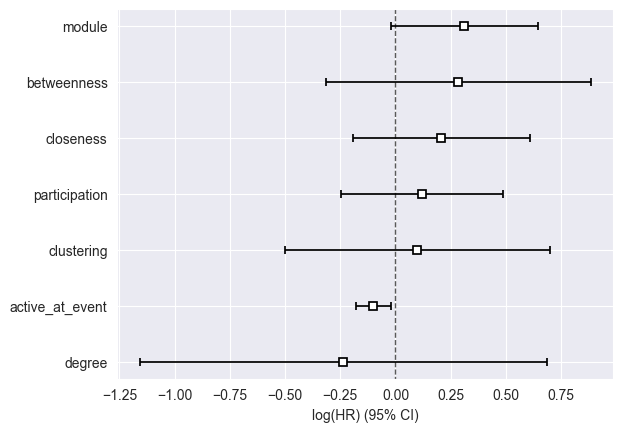

In [51]:
cph.plot()

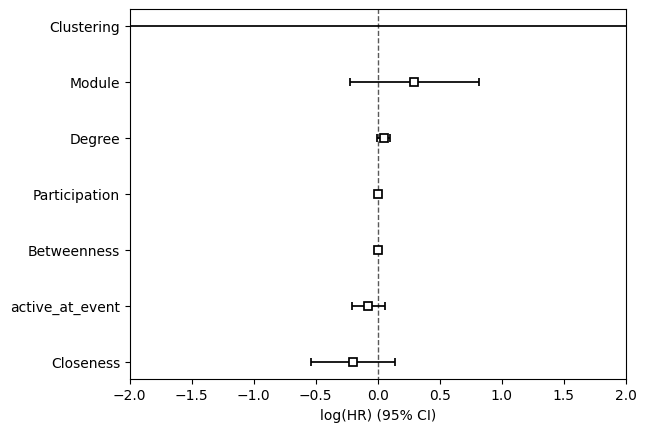

In [134]:
# # before scaling
#
# ax = cph.plot()
# ax.set_xlim(-2, 2)
# plt.show()

### Test bottleneck distances

Graph A — 0 finite H1,  52 essential (inf)
Graph B — 0 finite H1,  0 essential (inf)
Graph A — 52 total H1 pairs (incl. essential)
Graph B — 0 total H1 pairs (incl. essential)
Bottleneck distance d∞ = 0.7370


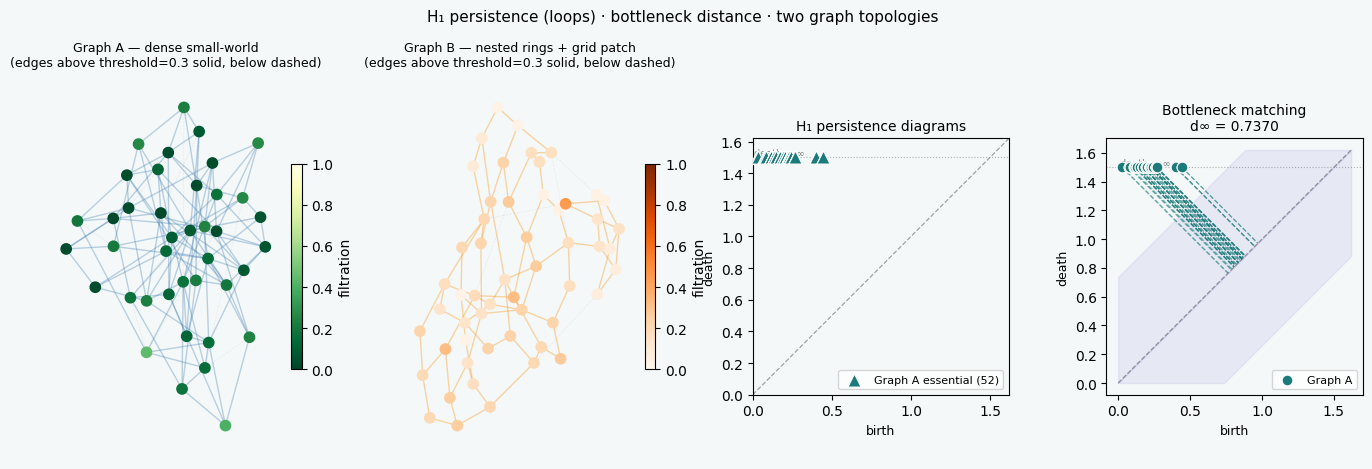

In [15]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import gudhi

# ── 1. Two graphs with weighted edges ────────────────────────────
# Edge weight = "connection strength" in [0, 1].
# We only include an edge in the simplex tree if weight >= THRESHOLD,
# so weak connections are pruned before the filtration.
THRESHOLD = 0.3
rng = np.random.default_rng(42)

def add_weighted_edges(G, edge_list, w_low=0.2, w_high=1.0):
    """Add edges with random weights drawn from [w_low, w_high]."""
    for e in edge_list:
        w = rng.uniform(w_low, w_high)
        G.add_edge(*e, weight=w)

# Graph A: dense small-world
GA = nx.watts_strogatz_graph(40, 6, 0.7, seed=1)
# assign random weights to existing edges
for u, v in GA.edges():
    GA[u][v]['weight'] = rng.uniform(0.2, 1.0)

# Graph B: nested rings + grid patch
GB = nx.Graph()

# outer ring — strong connections
add_weighted_edges(GB, [(i,(i+1)%30) for i in range(30)], 0.6, 1.0)
# inner ring — moderate connections
add_weighted_edges(GB, [(30+i, 30+(i+1)%15) for i in range(15)], 0.4, 0.9)
# spokes outer→inner — varied
for i in range(15):
    GB.add_edge(i*2, 30+i, weight=rng.uniform(0.3, 0.8))
# 3x3 grid patch
for r in range(3):
    for c in range(3):
        n = 45 + r*3 + c
        GB.add_node(n)
        if c < 2: GB.add_edge(n, n+1, weight=rng.uniform(0.4, 1.0))
        if r < 2: GB.add_edge(n, n+3, weight=rng.uniform(0.4, 1.0))
# attach grid to outer ring — weak bridges (some may be pruned)
add_weighted_edges(GB, [(45,5),(47,10),(51,15),(53,20)], 0.2, 0.6)
# long-range bridges — weak (likely pruned by threshold)
add_weighted_edges(GB, [(0,20),(5,25),(10,15),(30,37),(32,39),(34,41)], 0.1, 0.5)
# inner ring cross-links — moderate
add_weighted_edges(GB, [(30,33),(31,34),(32,35),(33,36)], 0.35, 0.75)

# ── 2. Filtration: (1 - weight) so strong edges enter early ──────
# Strong edges (high weight) get low filtration values → enter first.
# Weak edges (low weight) enter late, or are skipped entirely if below THRESHOLD.
def weighted_filtration(G):
    # node filtration = min (1 - weight) over all its edges above threshold
    # i.e. a node enters when its strongest surviving edge enters
    node_f = {}
    for n in G.nodes():
        edge_vals = [1.0 - d['weight']
                     for _, _, d in G.edges(n, data=True)
                     if d['weight'] >= THRESHOLD]
        node_f[n] = min(edge_vals) if edge_vals else 1.0
    return node_f

fA = weighted_filtration(GA)
fB = weighted_filtration(GB)

# ── 3. Build simplex trees — edges only inserted if weight >= THRESHOLD
def build_simplex_tree(G, node_filt):
    st = gudhi.SimplexTree()
    for n, f in node_filt.items():
        st.insert([n], filtration=f)
    for u, v, d in G.edges(data=True):
        if d['weight'] < THRESHOLD:          # ← weight condition
            continue
        f_edge = max(node_filt[u], node_filt[v])
        st.insert([u, v], filtration=f_edge)
    # 2-simplices (triangles) — only if all three edges pass threshold
    for u in G.nodes():
        for v in G.neighbors(u):
            if v <= u: continue
            if G[u][v]['weight'] < THRESHOLD: continue
            for w in G.neighbors(v):
                if w <= v: continue
                if not G.has_edge(u, w): continue
                if G[v][w]['weight'] < THRESHOLD: continue
                if G[u][w]['weight'] < THRESHOLD: continue
                f = max(node_filt[u], node_filt[v], node_filt[w])
                st.insert([u, v, w], filtration=f)
    st.make_filtration_non_decreasing()
    return st

stA = build_simplex_tree(GA, fA)
stB = build_simplex_tree(GB, fB)

stA.compute_persistence()
stB.compute_persistence()

# ── 4. Extract ALL H1 pairs (finite + essential) ─────────────────
# Essential classes (death=inf) represent loops never filled by a triangle.
# We replace inf with a sentinel value slightly above the max finite death,
# so they appear as tall points near the top edge of the diagram.
def get_h1(st):
    pairs = st.persistence_intervals_in_dimension(1)
    pairs = list(pairs)  # convert to plain list so len/bool work safely
    if len(pairs) == 0:
        return [], []
    finite   = [(b, d) for b, d in pairs if  np.isfinite(d)]
    infinite = [(b, d) for b, d in pairs if not np.isfinite(d)]
    return finite, infinite

h1A_fin, h1A_inf = get_h1(stA)
h1B_fin, h1B_inf = get_h1(stB)

print(f"Graph A — {len(h1A_fin)} finite H1,  {len(h1A_inf)} essential (inf)")
print(f"Graph B — {len(h1B_fin)} finite H1,  {len(h1B_inf)} essential (inf)")

# For bottleneck distance GUDHI needs finite values only;
# replace inf deaths with sentinel for the distance call too.
all_finite_deaths = [d for b,d in h1A_fin + h1B_fin]
sentinel = (max(all_finite_deaths) * 1.25) if all_finite_deaths else 1.5

def to_array(finite, infinite, sent):
    rows = list(finite) + [(b, sent) for b, _ in infinite]
    return np.array(rows) if rows else np.empty((0, 2))

dgmA = to_array(h1A_fin, h1A_inf, sentinel)
dgmB = to_array(h1B_fin, h1B_inf, sentinel)

print(f"Graph A — {len(dgmA)} total H1 pairs (incl. essential)")
print(f"Graph B — {len(dgmB)} total H1 pairs (incl. essential)")

bnd = gudhi.bottleneck_distance(dgmA, dgmB)
print(f"Bottleneck distance d∞ = {bnd:.4f}")

# ── 5. Greedy matching ────────────────────────────────────────────
def greedy_match(dA, dB):
    used, matches = set(), []
    for a in dA:
        best_j, best_c = -1, np.inf
        for j, b in enumerate(dB):
            if j in used: continue
            c = max(abs(a[0]-b[0]), abs(a[1]-b[1]))
            if c < best_c: best_c, best_j = c, j
        if best_j >= 0:
            used.add(best_j)
            matches.append((a, dB[best_j], best_c))
        else:
            matches.append((a, None, (a[1]-a[0])/2))
    for j, b in enumerate(dB):
        if j not in used:
            matches.append((None, b, (b[1]-b[0])/2))
    return matches

matches  = greedy_match(dgmA, dgmB)
bot_cost = max((c for _,_,c in matches), default=0)

# ── 6. Plot ───────────────────────────────────────────────────────
COL_A = '#1B7A7A'
COL_B = '#C04F15'
COL_MT= '#7060cc'
COL_BN= '#2a0a8f'
BG    = '#F4F8F8'

fig = plt.figure(figsize=(17, 5), facecolor=BG)
gs  = gridspec.GridSpec(1, 4, width_ratios=[1,1,1,1], wspace=0.38)

all_vals = np.concatenate([dgmA.ravel(), dgmB.ravel()]) \
           if (len(dgmA) and len(dgmB)) else np.array([0.0, 1.0])
lo, hi = 0.0, max(all_vals.max(), sentinel) * 1.08

# ── Panel 1: Graph A ──────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0]); ax0.set_facecolor(BG)
posA = nx.spring_layout(GA, seed=3)
wA = np.array([GA[u][v]['weight'] for u,v in GA.edges()])
abv_A = [(u,v) for u,v,d in GA.edges(data=True) if d['weight'] >= THRESHOLD]
blw_A = [(u,v) for u,v,d in GA.edges(data=True) if d['weight'] <  THRESHOLD]
nx.draw_networkx_edges(GA, posA, ax=ax0, edgelist=abv_A,
                       alpha=0.35, edge_color='steelblue', width=1.0)
nx.draw_networkx_edges(GA, posA, ax=ax0, edgelist=blw_A,
                       alpha=0.12, edge_color='gray', width=0.5, style='dashed')
nc0 = nx.draw_networkx_nodes(GA, posA, ax=ax0,
        node_color=[fA[n] for n in GA.nodes()],
        cmap=plt.cm.YlGn_r, node_size=55, vmin=0, vmax=1)
plt.colorbar(nc0, ax=ax0, fraction=0.04, pad=0.02, label='filtration')
ax0.set_title(f"Graph A — dense small-world\n"
              f"(edges above threshold={THRESHOLD} solid, below dashed)", fontsize=9)
ax0.axis('off')

# ── Panel 2: Graph B ──────────────────────────────────────────────
ax1 = fig.add_subplot(gs[1]); ax1.set_facecolor(BG)
posB = nx.spring_layout(GB, seed=12)
abv_B = [(u,v) for u,v,d in GB.edges(data=True) if d['weight'] >= THRESHOLD]
blw_B = [(u,v) for u,v,d in GB.edges(data=True) if d['weight'] <  THRESHOLD]
nx.draw_networkx_edges(GB, posB, ax=ax1, edgelist=abv_B,
                       alpha=0.35, edge_color='darkorange', width=1.0)
nx.draw_networkx_edges(GB, posB, ax=ax1, edgelist=blw_B,
                       alpha=0.12, edge_color='gray', width=0.5, style='dashed')
nc1 = nx.draw_networkx_nodes(GB, posB, ax=ax1,
        node_color=[fB[n] for n in GB.nodes()],
        cmap=plt.cm.Oranges, node_size=55, vmin=0, vmax=1)
plt.colorbar(nc1, ax=ax1, fraction=0.04, pad=0.02, label='filtration')
ax1.set_title(f"Graph B — nested rings + grid patch\n"
              f"(edges above threshold={THRESHOLD} solid, below dashed)", fontsize=9)
ax1.axis('off')

# ── Panel 3: H1 persistence diagrams overlaid ────────────────────
ax2 = fig.add_subplot(gs[2]); ax2.set_facecolor(BG); ax2.set_aspect('equal')
ax2.plot([lo,hi],[lo,hi],'k--',lw=0.9,alpha=0.35)
finA = np.array(h1A_fin) if h1A_fin else np.empty((0,2))
infA = np.array([(b, sentinel) for b,_ in h1A_inf]) if h1A_inf else np.empty((0,2))
finB = np.array(h1B_fin) if h1B_fin else np.empty((0,2))
infB = np.array([(b, sentinel) for b,_ in h1B_inf]) if h1B_inf else np.empty((0,2))

if len(finA):
    ax2.scatter(finA[:,0],finA[:,1],c=COL_A,s=60,zorder=4,
                edgecolors='white',linewidths=0.8,label=f'Graph A finite ({len(finA)})')
if len(infA):
    ax2.scatter(infA[:,0],infA[:,1],c=COL_A,s=90,zorder=4,
                edgecolors='white',linewidths=0.8,marker='^',
                label=f'Graph A essential ({len(infA)})')
if len(finB):
    ax2.scatter(finB[:,0],finB[:,1],c=COL_B,s=60,zorder=4,
                edgecolors='white',linewidths=0.8,label=f'Graph B finite ({len(finB)})')
if len(infB):
    ax2.scatter(infB[:,0],infB[:,1],c=COL_B,s=90,zorder=4,
                edgecolors='white',linewidths=0.8,marker='^',
                label=f'Graph B essential ({len(infB)})')

# dashed line marking the sentinel (= infinity)
ax2.axhline(sentinel, color='gray', lw=0.8, ls=':', alpha=0.6)
ax2.text(lo+0.01, sentinel+0.01, 'death = ∞', fontsize=7, color='gray')
ax2.set_xlim(lo,hi); ax2.set_ylim(lo,hi)
ax2.set_xlabel('birth',fontsize=9); ax2.set_ylabel('death',fontsize=9)
ax2.set_title('H₁ persistence diagrams',fontsize=10)
ax2.legend(fontsize=8)

# ── Panel 4: bottleneck matching ─────────────────────────────────
ax3 = fig.add_subplot(gs[3]); ax3.set_facecolor(BG); ax3.set_aspect('equal')
ax3.plot([lo,hi],[lo,hi],'k--',lw=0.9,alpha=0.35)

band = np.linspace(lo, hi, 300)
ax3.fill_between(band, band, np.minimum(band+bnd, hi),
                 alpha=0.10, color=COL_MT)
ax3.fill_between(band, np.maximum(band-bnd, lo), band,
                 alpha=0.10, color=COL_MT)

for a, b, cost in matches:
    is_bot = (a is not None and b is not None
              and np.isclose(cost, bot_cost, atol=1e-9))
    if a is not None and b is not None:
        ax3.plot([a[0],b[0]],[a[1],b[1]],
                 color=COL_BN if is_bot else COL_MT,
                 lw=2.5   if is_bot else 1.1,
                 alpha=1.0 if is_bot else 0.55,
                 zorder=5  if is_bot else 3)
    elif a is not None:
        mid = (a[0]+a[1])/2
        ax3.plot([a[0],mid],[a[1],mid],'--',c=COL_A,lw=0.9,alpha=0.45)
    elif b is not None:
        mid = (b[0]+b[1])/2
        ax3.plot([b[0],mid],[b[1],mid],'--',c=COL_B,lw=0.9,alpha=0.45)

if len(dgmA):
    ax3.scatter(dgmA[:,0],dgmA[:,1],c=COL_A,s=60,zorder=6,
                edgecolors='white',linewidths=0.8,label='Graph A')
if len(dgmB):
    ax3.scatter(dgmB[:,0],dgmB[:,1],c=COL_B,s=60,zorder=6,
                edgecolors='white',linewidths=0.8,label='Graph B')

ax3.axhline(sentinel, color='gray', lw=0.8, ls=':', alpha=0.6)
ax3.text(lo+0.01, sentinel+0.01, 'death = ∞', fontsize=7, color='gray')
ax3.set_xlabel('birth',fontsize=9); ax3.set_ylabel('death',fontsize=9)
ax3.set_title(f'Bottleneck matching\nd∞ = {bnd:.4f}',fontsize=10)
ax3.legend(fontsize=8)

plt.suptitle('H₁ persistence (loops) · bottleneck distance · two graph topologies',
             fontsize=11, y=1.01)
plt.savefig('bottleneck_h1.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()